In [75]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys, os
# Project Path Setup
from setup_project_path import check_and_add_project_path  # Script to check and add project path
check_and_add_project_path()


# Import Custom Modules
from src.utils.module_utils.all_custom_modules import cf, DataInterp, Hdf5Kernel, fit_logarithmic, log_func # Consolidated custom modules import
import src.utils.common_funcs as cf



In [76]:
filename_ID = f'../data/ID_delta_t=0.1_flatband_Lambda=10.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)

In [77]:
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont"]

#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

errors_discretization = data_h5_ID["eps"]
m_vals = data_h5_ID["m"] #factor 2 for positive and negative frequencies
n_vals = data_h5_ID["n"] #factor 2 for positive and negative frequencies
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]
N_modes_finegrid = 2*(m_vals + n_vals)

print(f"Errors Discretization: {errors_discretization}")
print(f"Errors ID: {errors_ID}")


Errors Discretization: [[[3.00479284e-10 1.72290854e-06]
  [1.96663110e-10 6.10506816e-06]
  [1.45056426e-10 2.48797851e-05]]

 [[8.45940786e-06 1.37227927e-05]
  [5.53674158e-06 1.35971729e-05]
  [4.08395996e-06 3.03790757e-05]]

 [[2.42455213e-04 4.46522539e-04]
  [1.58641584e-04 2.85122163e-04]
  [1.17039131e-04 2.26616572e-04]]

 [[2.86230006e-03 3.11193560e-03]
  [1.87158710e-03 1.96174308e-03]
  [1.37990805e-03 1.43483057e-03]]

 [[8.92356036e-03 1.63271443e-02]
  [5.82118538e-03 1.02998640e-02]
  [4.28941624e-03 7.45228763e-03]]

 [[2.06196181e-02 2.82218378e-02]
  [1.39634456e-02 1.84039727e-02]
  [1.06544235e-02 1.37793379e-02]]]
Errors ID: [[[3.00479277e-10 1.72291071e-06]
  [2.13056960e-10 6.22005535e-06]
  [1.93182437e-10 2.50899982e-05]]

 [[9.47629359e-06 1.43770203e-05]
  [6.34360680e-06 1.38100997e-05]
  [8.97568569e-06 3.05616324e-05]]

 [[3.04332942e-04 4.80163458e-04]
  [1.83252423e-04 3.18606382e-04]
  [1.80662972e-04 2.76084773e-04]]

 [[3.20097129e-03 3.47197209e-

In [78]:
filename_AAA = f'../data/AAA_delta_t=0.1_flatband_Lambda=10.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA = Hdf5Kernel(filename=filename_AAA)

In [79]:
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["m", "n", "h",  "beta",  "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol"]

kernel_dims_AAA, data_h5_AAA = h5_kernel_AAA.read_scalars_to_array(keys=keys)

m_vals = data_h5_AAA["m"]
n_vals = data_h5_AAA["n"]
h_vals = data_h5_AAA["h"]
betas = data_h5_AAA["beta"]
errors_AAA = data_h5_AAA["AAA_error_reconstr_vs_cont"]
nbr_poles_upper = data_h5_AAA["nbr_poles_upper"]
tol_vals = data_h5_AAA["tol"]

print(f"Dimensions of data arrays: {kernel_dims_AAA}.")
print("errors AAA ", errors_AAA)
print("nbr_poles_upper ", nbr_poles_upper)




Dimensions of data arrays: [4 3 2].
errors AAA  [[[1.40569689e-03 3.11122225e-03]
  [2.28054342e-03 3.99524054e-03]
  [2.42747246e-03 3.84526584e-03]]

 [[8.03409083e-06 1.54039930e-05]
  [1.63521617e-05 2.41788832e-05]
  [2.84553349e-05 2.60010581e-05]]

 [[1.36872523e-07 5.31509614e-08]
  [2.15082428e-07 1.29081931e-07]
  [2.89916766e-07 2.11472155e-07]]

 [[3.06329610e-09 2.90874584e-07]
  [3.73973608e-09 2.04768033e-07]
  [4.96747478e-09 1.66713905e-07]]]
nbr_poles_upper  [[[18 27]
  [18 27]
  [18 27]]

 [[24 44]
  [24 44]
  [24 44]]

 [[30 58]
  [30 58]
  [30 58]]

 [[34 69]
  [34 69]
  [34 69]]]


1.7229107087700857e-06


/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/src/utils/plot_utils.py:27: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(log_func, x_data, y_data)
/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_67246/2315283122.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars


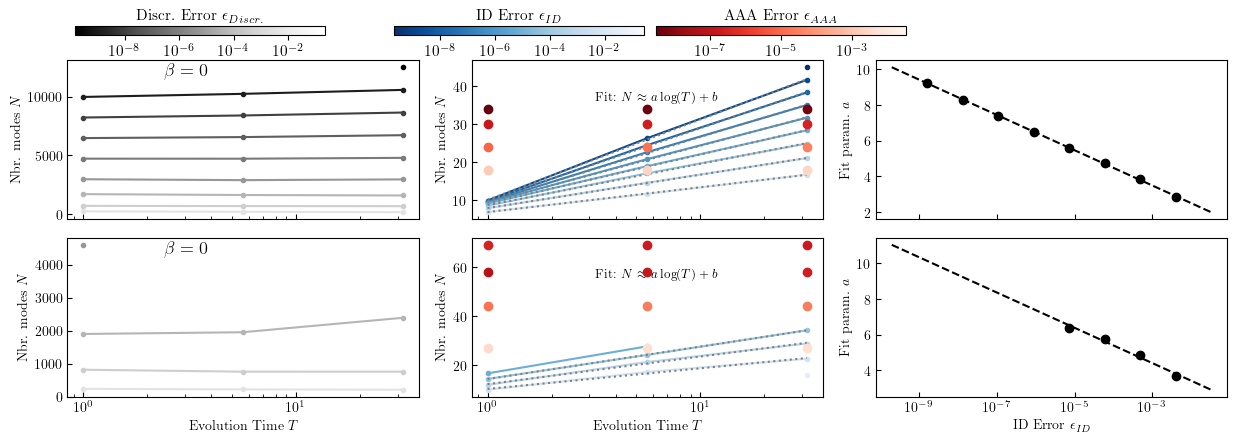

In [80]:
# Set global fontsize using rcParams

cmap_blues = plt.get_cmap("Blues_r")
cmap_reds = plt.get_cmap("Reds_r")
cmap_grays = plt.get_cmap("Greys_r")
# Configuration and data preparation
nbr_interpolations = 10

error_grid_AAA = np.logspace(np.log10(np.min(errors_AAA)), np.log10(np.max(errors_AAA)), nbr_interpolations)

#lower_bound = np.max([np.min(errors_ID), np.min(errors_discretization)])
#upper_bound = np.min([np.max(errors_ID), np.max(errors_discretization)])
print(np.min(errors_ID[:,:,1]))
#print(lower_bound, upper_bound)
#if lower_bound >= upper_bound:
#    print("Error bounds are not consistent. Please check the data.")
#    sys.exit()
#else:
error_grid_discretization = np.logspace(np.log10(np.min(errors_discretization)), np.log10(np.max(errors_discretization)), nbr_interpolations)
error_grid_ID = np.logspace(np.log10(np.min(errors_ID)), np.log10(np.max(errors_ID)), nbr_interpolations)


fig, axs = plt.subplots(kernel_dims_ID[2], 3, figsize=(12.5, 4.5))
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 11})

N_modes_finegrid_interp = np.zeros((len(error_grid_discretization), kernel_dims_ID[1]))
ID_ranks_interp = np.zeros((len(error_grid_ID), kernel_dims_ID[1]))

t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

# Use logarithmic normalization
norm_bare = mcolors.LogNorm(vmin=np.min(error_grid_discretization[error_grid_discretization > 0]), vmax=8*np.max(error_grid_discretization))
norm_AAA = mcolors.LogNorm(vmin=np.min(errors_AAA[errors_AAA > 0]), vmax=8*np.max(errors_AAA))
norm_ID = mcolors.LogNorm(vmin=np.min(errors_ID[errors_ID > 0]), vmax=8*np.max(errors_ID))


        
# Interpolation and plotting ID data
for b in range (kernel_dims_ID[2]):#loop over beta values

    fitting_params_a = np.zeros((len(error_grid_ID),))

    for tau in range (kernel_dims_ID[1]):#loop over final time values, N_max
        mask_discretization = errors_discretization[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        mask_ID = errors_ID[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        N_MODES_FINE_INTERP = DataInterp(errors_discretization[mask_discretization, tau,b], N_modes_finegrid[mask_discretization, tau,b])
        ID_RANKS_INTERP = DataInterp(errors_ID[mask_ID, tau,b], ID_ranks[mask_ID, tau,b])

        N_modes_finegrid_interp[:, tau] = N_MODES_FINE_INTERP.interp(error_grid_discretization, x_scale='log')
        ID_ranks_interp[:, tau] = ID_RANKS_INTERP.interp(error_grid_ID, x_scale='log')    
      
        

    for eps_iter in range(len(error_grid_discretization)):
        #plot only nonzero values
        mask_N_modes_fine = N_modes_finegrid_interp[eps_iter, :] > 0.
        mask_ID = ID_ranks_interp[eps_iter, :] > 0.
        error_bare = error_grid_discretization[eps_iter]
        error_ID = error_grid_ID[eps_iter]

        axs[b,0].plot(t_data[mask_N_modes_fine], N_modes_finegrid_interp[eps_iter, mask_N_modes_fine], marker="o", linestyle="-", markersize=3, color=cmap_grays(norm_bare(error_bare)))
        axs[b,1].plot(t_data[mask_ID], ID_ranks_interp[eps_iter, mask_ID], marker="o", linestyle="-", markersize=3, color=cmap_blues(norm_ID(error_ID)))    
        #fit logarithmic curves
        if sum(mask_ID) > 1:
            params = fit_logarithmic(t_data[mask_ID][:], ID_ranks_interp[eps_iter, mask_ID][:])
            fitting_params_a[eps_iter] = params[0]

            axs[b,1].plot(t_data[mask_N_modes_fine], log_func(t_data[mask_N_modes_fine], *params),  color="gray", linestyle = 'dotted')
        
    
            #plot fitting parameters
            axs[b,2].scatter(error_ID, params[0], marker="o",  color="black", label = r'$a$')

    for tau in range(kernel_dims_AAA[1]):
        for tol_iter, tol_val in enumerate(tol_vals[:,tau,b]):
            axs[b,1].scatter(t_data[tau], nbr_poles_upper[tol_iter, tau, b], marker="o", color=cmap_reds(norm_AAA(errors_AAA[tol_iter,tau,b])), zorder = 10)


    mask_fitting_params = fitting_params_a > 0.
    if np.sum(mask_fitting_params) > 1:
        a_fitting_params= fit_logarithmic(error_grid_ID[mask_fitting_params], fitting_params_a[mask_fitting_params])
        axs[b,2].plot(error_grid_ID, log_func(error_grid_ID,*a_fitting_params), color = 'black', linestyle = 'dashed')

    axs[b, 0].set_title(r'$\beta = 0$', loc='right', x = .4, y=0.85)
    axs[b, 1].set_title(r'$\beta = \infty$', loc='right', x = .4, y=0.85)
    axs[b, 1].set_title("Fit: "+ r'$N \approx a \log (T) + b$', loc='right', x = .7, y=0.7, fontsize = "small")
    #axs[b, 2].set_title("Fitting function: \n" + r'$y = {} \log (\epsilon) {}$'.format(*np.round(a_fitting_params,2)), loc='right', x = .9, y=0.7)
    

    axs[b,0].set_ylabel("Nbr. modes " + r"$N$")
    axs[b,1].set_ylabel("Nbr. modes " + r"$N$")
    axs[b,2].set_ylabel("Fit param. " + r'$a$')
  

    axs[b,0].set_xscale('log')
    axs[b,1].set_xscale('log')
    axs[b,2].set_xscale('log')



    
# Setting labels and legend
axs[-1,0].set_xlabel("Evolution Time " + r'$T$')
axs[-1,1].set_xlabel("Evolution Time " + r'$T$')
axs[-1,2].set_xlabel("ID Error " + r'$\epsilon_{ID}$')

# Add a colorbar for the grays above the figure
cax_grays = fig.add_axes([0.065, 0.92, 0.2, 0.02])
sm_grays = cm.ScalarMappable(cmap=cmap_grays, norm=norm_bare)
sm_grays.set_array([])
cbar_grays = fig.colorbar(sm_grays, cax=cax_grays, orientation='horizontal')
cbar_grays.set_label('Discr. Error ' + r'$\epsilon_{Discr.}$', labelpad=-35)

# Add a colorbar for the blues above the figure
cax_blues = fig.add_axes([0.32, 0.92, 0.2, 0.02])
sm_blues = cm.ScalarMappable(cmap=cmap_blues, norm=norm_ID)
sm_blues.set_array([])
cbar_blues = fig.colorbar(sm_blues, cax=cax_blues, orientation='horizontal')
cbar_blues.set_label('ID Error ' + r'$\epsilon_{ID}$', labelpad=-35)

# Add a colorbar for the reds above the figure
cax_reds = fig.add_axes([0.53, 0.92, 0.2, 0.02])
sm_reds = cm.ScalarMappable(cmap=cmap_reds, norm=norm_AAA)
sm_reds.set_array([])
cbar_reds = fig.colorbar(sm_reds, cax=cax_reds, orientation='horizontal')
cbar_reds.set_label('AAA Error ' + r'$\epsilon_{AAA}$', labelpad=-35)

#remove tick labels from upper plots
for i in range(3):
    axs[0,i].set_xticklabels([])

#move all ticks into plotting area
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#move lower plots closer to upper plots, such that the upper edge of the lower plots zouces with the lower edge of the upper plots. do not use subplots_adjust
fig.subplots_adjust(hspace=0.0, wspace=0.0)


plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars


#plt.savefig("../plots/modes_vs_time_no_opt.pdf", bbox_inches='tight')


IndexError: index 3 is out of bounds for axis 1 with size 3

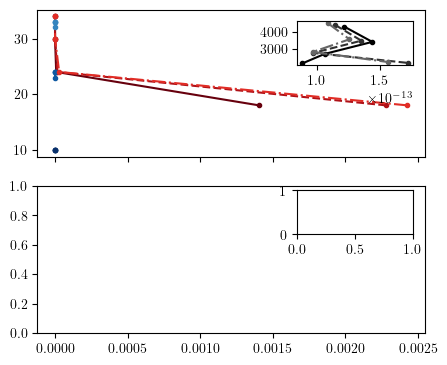

In [84]:
# Set global fontsize using rcParams
from itertools import cycle

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['-', '--', '-.', ':']
    return cycle(predefined_linestyles[:n])

linestyles = generate_linestyles_cycler(kernel_dims_ID[1])
linecycler = cycle(linestyles)

fig, axs = plt.subplots(2, 1, figsize=(5, 4.2), sharex=True)
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})
# Create insets for subplots
axs_inset = [axs[0].inset_axes([0.67, 0.62, 0.3, 0.3]), axs[1].inset_axes([0.67, 0.67, 0.3, 0.3])]

# Collect handles and labels for the legend
handles_AAA = []
labels_AAA = []
handles_ID = []
labels_ID = []
handles_bare = []
labels_bare = []

norm_times = mcolors.LogNorm(vmin=np.min(t_data[t_data > 0]), vmax=8*np.max(t_data))

for b in range(kernel_dims_ID[2]):
    for tau in range(kernel_dims_ID[1]):
        err_AAA = []
        nbr_poles = []
        err_ID = []
        ID_modes = []
        err_disc = []
        nbr_bare_modes = []
        for tol_iter in range(tol_vals.shape[0]):
            err_AAA.append(errors_AAA[tol_iter, tau, b])
            err_ID.append(errors_ID[tol_iter, tau, b])
            err_disc.append(errors_discretization[tol_iter, tau, b])
            nbr_poles.append(nbr_poles_upper[tol_iter, tau, b])
            ID_modes.append(ID_ranks[tol_iter, tau, b])
            nbr_bare_modes.append(N_modes_finegrid[tol_iter, tau, b])

        linestyle = next(linecycler)

        line_AAA, = axs[b].plot(err_AAA, nbr_poles, marker="o", linestyle=linestyle, markersize=3, 
                                color=cmap_reds(norm_times(t_data[tau])), label=r'$t = {}$'.format(round(t_data[tau], 2)))
        line_ID, = axs[b].plot(err_ID, ID_modes, marker="o", linestyle=linestyle, markersize=3, 
                               color=cmap_blues(norm_times(t_data[tau])), label=r'$t = {}$'.format(round(t_data[tau], 2)))

        line_bare, = axs_inset[b].plot(err_disc, nbr_bare_modes, marker="o", linestyle=linestyle, markersize=3, color=cmap_grays(norm_times(t_data[tau])), 
                          label=r'$t = {}$'.format(round(t_data[tau], 2)))

        # Collect legend handles and labels for unique time values
        if line_bare.get_label() not in labels_bare:
            handles_bare.append(line_bare)
            labels_bare.append(line_bare.get_label())
        if line_AAA.get_label() not in labels_AAA:
            handles_AAA.append(line_AAA)
            labels_AAA.append(line_AAA.get_label())
        if line_ID.get_label() not in labels_ID:
            handles_ID.append(line_ID)
            labels_ID.append(line_ID.get_label())


    axs[b].set_ylabel("Nbr. of modes " + r"$N$")
    axs[b].set_xscale("log")
    axs_inset[b].set_xscale("log")
    axs_inset[b].set_xlabel(r"$\epsilon$", labelpad=-3)
    axs_inset[b].set_ylabel(r"$N$", labelpad=-5)

axs[1].set_xlabel("Error " + r"$\epsilon$")

axs[0].text(0.4, 0.85, r"$\beta = 0$", transform=axs[0].transAxes, )
axs[1].text(0.4, 0.85, r"$\beta = \infty$", transform=axs[1].transAxes)

# Add a single legend above the entire figure
from matplotlib.legend import Legend

# Create custom legends
legend1 = Legend(fig, handles_ID, labels_ID, loc='upper center', ncol=len(t_data), fontsize='small', title="ID (Blue Curves)")
legend2 = Legend(fig, handles_AAA, labels_AAA, loc='upper center', ncol=len(t_data), fontsize='small', title="AAA (Red Curves)")
legend3 = Legend(fig, handles_bare, labels_bare, loc='upper center', ncol=3, fontsize='small', frameon=False)

# Add the legends manually
#fig.add_artist(legend1)
#fig.add_artist(legend2)
fig.add_artist(legend3)


# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])
#legend1.set_bbox_to_anchor((0.5, 0.95))
#legend2.set_bbox_to_anchor((0.5, 1.007))
legend3.set_bbox_to_anchor((0.73, .95))



# Define custom legend elements for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap_grays(0.4), edgecolor=cmap_grays(0.4), label='Exp. Freq. Parametrization'),
                   Patch(facecolor=cmap_blues(0.4), edgecolor=cmap_blues(0.4), label='Interpolative Decomposition'),
                   Patch(facecolor=cmap_reds(0.4), edgecolor=cmap_reds(0.4), label='AAA Approximation'),]

# Create custom legend
legend = plt.legend(handles=legend_elements, loc='upper center', ncol=1, bbox_to_anchor=(0.14, 2.3), fontsize='medium', frameon=False)

# Add the custom legend to the figure
fig.add_artist(legend)

#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')
#same for insets
for ax in axs_inset:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')


#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

plt.show()

Dimensions of data arrays: [6 3 2].
errors AAA  [[[7.87018627e-04 7.01557319e-04]
  [1.05396145e-03 4.80483943e-04]
  [2.97468245e-03 9.07784892e-04]]

 [[2.84706610e-05 7.05414751e-05]
  [9.20636100e-05 9.07813734e-05]
  [4.19600678e-04 3.41717316e-04]]

 [[1.50373485e-05 6.63862430e-05]
  [7.14117650e-05 9.78180409e-05]
  [3.43997735e-04 3.52632058e-04]]

 [[1.54752368e-04 1.04837535e-04]
  [3.70126829e-04 1.13717677e-04]
  [1.66668411e-03 3.88487594e-04]]

 [[7.80820260e-05 1.18690523e-04]
  [2.04026854e-04 1.70499344e-04]
  [8.78670784e-04 6.67481265e-04]]

 [[5.03820195e-05 1.18690523e-04]
  [1.08297323e-04 1.70499344e-04]
  [4.59205685e-04 6.67481265e-04]]]
nbr_poles_upper  [[[18 30]
  [18 30]
  [18 30]]

 [[30 42]
  [30 42]
  [30 42]]

 [[40 58]
  [40 58]
  [40 58]]

 [[48 53]
  [48 53]
  [48 53]]

 [[58 51]
  [58 51]
  [58 51]]

 [[70 51]
  [70 51]
  [70 51]]]


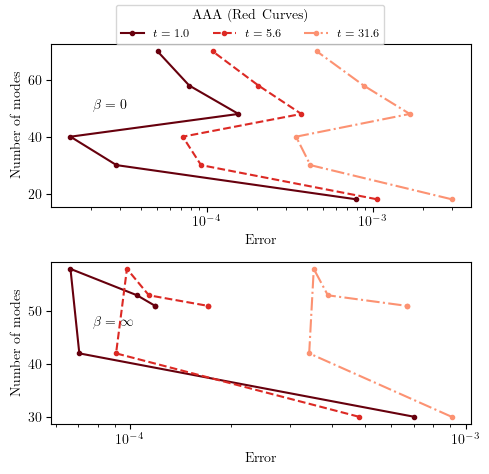

In [82]:

filename_AAA_sc = f'../data/AAA_delta_t=0.1_semicircle_Lambda=1.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA_sc = Hdf5Kernel(filename=filename_AAA_sc)

#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys_sc = ["m", "n", "h",  "beta", "N_max", "delta_t", "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA_sc.read_scalars_to_array(keys=keys_sc)

errors_AAA_sc = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
nbr_poles_upper_sc = data_h5_AAA_sc["nbr_poles_upper"]
N_maxs_sc = data_h5_AAA_sc["N_max"]
betas_sc = data_h5_AAA_sc["beta"]
delta_t_vals_sc = data_h5_AAA_sc["delta_t"]
tol_vals_sc = data_h5_AAA_sc["tol"]

t_data = np.array([np.max(N_maxs_sc[:,tau,:] * delta_t_vals_sc[:,tau,:]) for tau in range (kernel_dims_AAA_sc[1])])

print(f"Dimensions of data arrays: {kernel_dims_AAA_sc}.")
print("errors AAA ", errors_AAA_sc)
print("nbr_poles_upper ", nbr_poles_upper_sc)


cmap_reds = plt.get_cmap("Reds_r")



# Set global fontsize using rcParams
plt.rcParams.update({'font.size': 10})
from itertools import cycle

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['-', '--', '-.', ':']
    return cycle(predefined_linestyles[:n])

linestyles = generate_linestyles_cycler(kernel_dims_AAA_sc[1])
linecycler = cycle(linestyles)

fig, axs = plt.subplots(2, 1, figsize=(5, 5))

# Collect handles and labels for the legend
handles_AAA = []
labels_AAA = []


norm_times = mcolors.LogNorm(vmin=np.min(t_data[t_data > 0]), vmax=8*np.max(t_data))

for b in range(kernel_dims_AAA_sc[2]):
    for tau in range(kernel_dims_AAA_sc[1]):
        err_AAA_sc = []
        nbr_poles_sc = []
       
        for tol_iter, tol_val in enumerate(tol_vals_sc[:, tau, b]):
            err_AAA_sc.append(errors_AAA_sc[tol_iter, tau, b])
            nbr_poles_sc.append(nbr_poles_upper_sc[tol_iter, tau, b])

        linestyle = next(linecycler)

        line_AAA, = axs[b].plot(err_AAA_sc, nbr_poles_sc, marker="o", linestyle=linestyle, markersize=3, 
                                color=cmap_reds(norm_times(t_data[tau])), label=r'$t = {}$'.format(round(t_data[tau], 2)))
     

        if line_AAA.get_label() not in labels_AAA:
            handles_AAA.append(line_AAA)
            labels_AAA.append(line_AAA.get_label())
      

    axs[b].set_xlabel("Error")
    axs[b].set_ylabel("Number of modes")
    axs[b].set_xscale("log")


axs[0].text(0.1, 0.6, r"$\beta = 0$", transform=axs[0].transAxes)
axs[1].text(0.1, 0.6, r"$\beta = \infty$", transform=axs[1].transAxes)

# Add a single legend above the entire figure
from matplotlib.legend import Legend

# Create custom legends
legend = Legend(fig, handles_AAA, labels_AAA, loc='upper center', ncol=len(t_data), fontsize='small', title="AAA (Red Curves)")

# Add the legends manually
fig.add_artist(legend)


# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])

legend.set_bbox_to_anchor((0.5, .95))

plt.show()


[20  5  2]


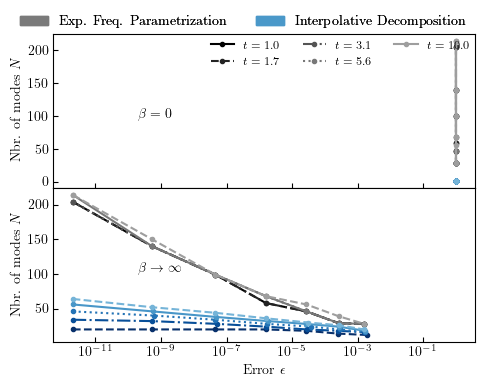

In [114]:
filename_ID = f'../data/test_ID.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)

#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont", "only_positive_particle"]

cmap_blues = plt.get_cmap("Blues_r")
cmap_reds = plt.get_cmap("Reds_r")
cmap_grays = plt.get_cmap("Greys_r")
#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

print(kernel_dims_ID)
errors_discretization = data_h5_ID["eps"]
m_vals = data_h5_ID["m"] 
n_vals = data_h5_ID["n"]
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]
N_modes_finegrid = (m_vals + n_vals)

t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

# Set global fontsize using rcParams
from itertools import cycle

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['-', '--', '-.', ':']
    return cycle(predefined_linestyles[:n])

linestyles = generate_linestyles_cycler(kernel_dims_ID[1])
linecycler = cycle(linestyles)

fig, axs = plt.subplots(2, 1, figsize=(5, 4.2), sharex=True)
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})

# Collect handles and labels for the legend
handles_ID = []
labels_ID = []
handles_bare = []
labels_bare = []

norm_times = mcolors.LogNorm(vmin=np.min(t_data[t_data > 0]), vmax=8*np.max(t_data))

for b in range(kernel_dims_ID[2]):
    for tau in range(kernel_dims_ID[1]):

        err_ID = []
        ID_modes = []
        err_disc = []
        nbr_bare_modes = []
        
        for iter in range (errors_ID.shape[0]):
            err_ID.append(errors_ID[iter, tau, b])
            err_disc.append(errors_discretization[iter, tau, b])
            ID_modes.append(ID_ranks[iter, tau, b])
            nbr_bare_modes.append(N_modes_finegrid[iter, tau, b])

        #convert arrays to numpy arrays
        err_ID = np.array(err_ID)
        ID_modes = np.array(ID_modes)
        err_disc = np.array(err_disc)
        nbr_bare_modes = np.array(nbr_bare_modes)

        linestyle = next(linecycler)
        mask_ID = err_ID > 1.e-12

        line_ID, = axs[b].plot(err_ID[mask_ID], ID_modes[mask_ID], marker="o", linestyle=linestyle, markersize=3, 
                               color=cmap_blues(norm_times(t_data[tau])), label=r'$t = {}$'.format(round(t_data[tau], 2)))


        mask_bare = err_disc > 1.e-12
    
        line_bare, = axs[b].plot(err_disc[mask_bare], nbr_bare_modes[mask_bare], marker="o", linestyle=linestyle, markersize=3, color=cmap_grays(norm_times(t_data[tau])), 
                          label=r'$t = {}$'.format(round(t_data[tau], 2)))

        # Collect legend handles and labels for unique time values
        if line_bare.get_label() not in labels_bare:
            handles_bare.append(line_bare)
            labels_bare.append(line_bare.get_label())

        if line_ID.get_label() not in labels_ID:
            handles_ID.append(line_ID)
            labels_ID.append(line_ID.get_label())


    
    axs[b].set_ylabel("Nbr. of modes " + r"$N$")
    axs[b].set_xscale("log")

axs[1].set_xlabel("Error " + r"$\epsilon$")
axs[0].text(0.2, 0.45, r"$\beta = 0$", transform=axs[0].transAxes, )
axs[1].text(0.2, 0.45, r"$\beta \to \infty$", transform=axs[1].transAxes)

# Add a single legend above the entire figure
from matplotlib.legend import Legend

# Create custom legends

legend3 = Legend(fig, handles_bare, labels_bare, loc='upper center', ncol=3, fontsize='small', frameon=False)

# Add the legends manually
fig.add_artist(legend3)


# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])

legend3.set_bbox_to_anchor((0.68, .85))



# Define custom legend elements for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap_grays(0.4), edgecolor=cmap_grays(0.4), label='Exp. Freq. Parametrization'),
                   Patch(facecolor=cmap_blues(0.4), edgecolor=cmap_blues(0.4), label='Interpolative Decomposition'),
                     ]

# Create custom legend
legend = plt.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.45, 2.2), fontsize='medium', frameon=False)

# Add the custom legend to the figure
fig.add_artist(legend)

#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

plt.show()
